In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

In [ ]:
df = pd.read_csv("../data/cilantro_stats.csv")
print(df.head())


,filename,day,group,mean_hue,std_hue,mean_saturation,std_saturation,mean_value,std_value,mean_blue,mean_green,mean_red
0,Day0_Group_1.jpg,0,1,40.948290,3.389168,173.123703,55.081587,73.235617,24.876272,27.663441,73.235617,57.063513
1,Day0_Group_2.jpg,0,2,41.467722,3.582719,160.065749,49.932959,75.343588,25.753415,31.932824,75.343588,59.240915
2,Day0_Group_3.jpg,0,3,39.521384,2.502218,169.683459,48.572876,83.104608,22.473927,31.104960,83.104608,66.966885
3,Day0_Group_4.jpg,0,4,41.934922,3.205031,157.830050,45.534254,79.868350,24.504946,33.702520,79.868350,61.913482
4,Day0_Group_5.jpg,0,5,39.061404,2.646530,180.027835,50.209855,71.202209,22.797837,24.686959,71.202209,57.403039



Generating heatmaps:
   group  day  avg_mean_saturation  avg_mean_hue   avg_mean
0      1    0           173.123703     40.948290  73.235617
1      1    1           157.567286     41.220506  67.664556
2      1    2           157.831467     41.103727  62.531266
3      1    3           144.937476     40.994470  59.567735
4      1    4           105.110916     43.182416  58.861078


Text(120.72222222222221, 0.5, 'Experimental Condition')

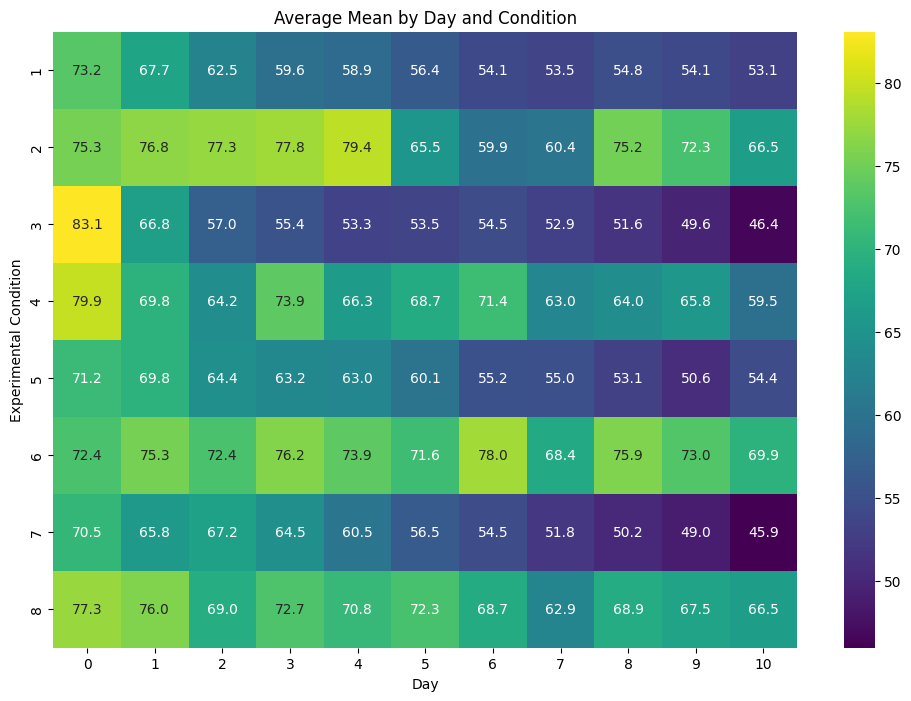

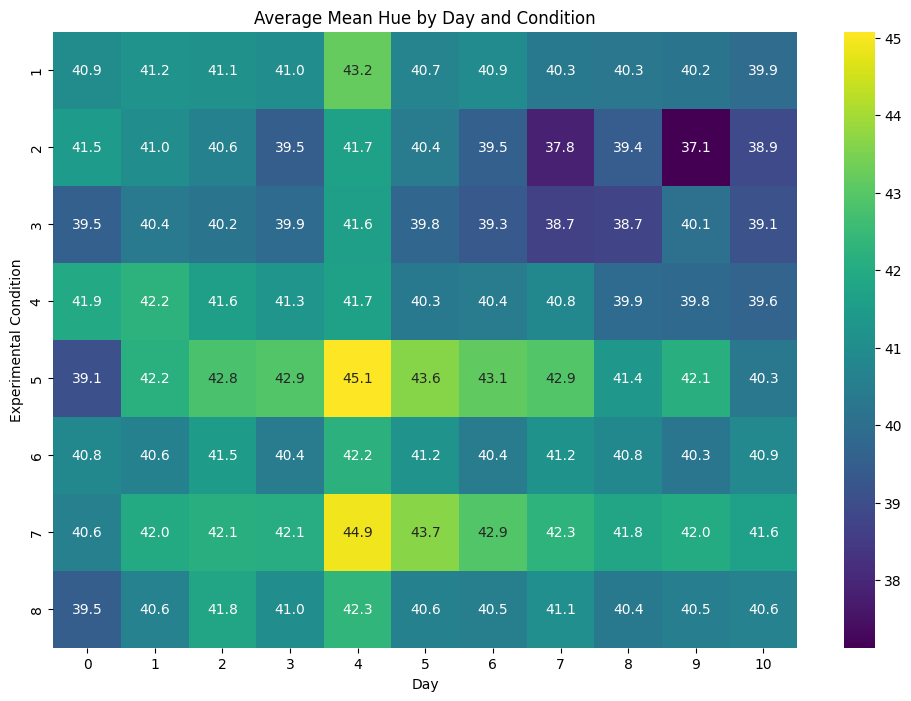

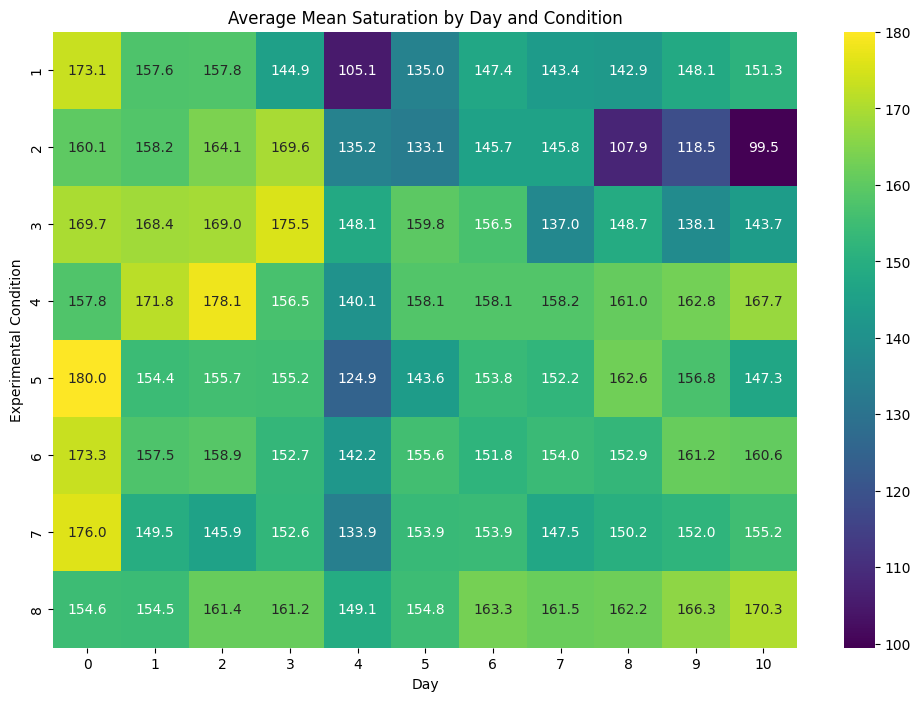

In [39]:
# --- Heatmap Generation ---
print("\nGenerating heatmaps:")

# Aggregate the data for the heatmaps
heatmap_data = df.groupby(['group', 'day']).agg(
    avg_mean_saturation=('mean_saturation', 'mean'),
    avg_mean_hue=('mean_hue', 'mean'),
    avg_mean = ('mean_value', 'mean')
    ).reset_index()

print(heatmap_data.head(5))

#draw the heatma: Rows = group, Columns = day, Values = saturation
heatmap_mean = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean'
)

heatmap_hue = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean_hue'
)

heatmap_sat = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean_saturation'
)
# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_mean, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Condition")


# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_hue, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean Hue by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Condition")

# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_sat, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean Saturation by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Condition")

In [47]:
## OLS model
groups = df['group'].unique()

slope_results = []

# Loop through each group and fit a model
for group_name in groups:
    group_data = df[df['group'] == group_name]
        
    # Fit the OLS model
    # 'mean_saturation ~ day' is the formula "Mean Saturation = B0 + B1*Day"
    model = smf.ols('mean_saturation ~ day', data=group_data).fit()
        
    # Extract the slope coefficient for 'day'
    slope = model.params['day']
        
    slope_results.append({
        'group': group_name,
        'slope': slope
    })

df_slopes = pd.DataFrame(slope_results)
print("Successfully extracted 8 slopes:")
print(df_slopes)

Successfully extracted 8 slopes:
   group     slope
0      1 -1.389620
1      2 -6.066950
2      3 -3.462952
3      4 -0.156708
4      5 -1.004285
5      6 -0.496751
6      7 -0.648986
7      8  1.298235


In [ ]:
## ANOVA model
